# Project 2 — Temporal Land-Cover Analysis

## Submission Overview

This project develops an end-to-end machine-learning workflow for estimating temporal land-cover patterns within a fixed Area of Interest (AOI) in Bengaluru, India.

Sentinel-2 Level-2A imagery from **2021, 2023, and 2025** is processed on a common 10 m UTM grid. ESA WorldCover 2021 is used as the reference dataset for model training and spatial validation, and a Random Forest classifier is applied to generate comparable land-cover maps for all three years.

### Objectives

- Prepare comparable Sentinel-2 observations for a fixed AOI.
- Apply quality masking and radiometric preprocessing.
- Derive spectral bands and land-cover indices.
- Generate reference labels from ESA WorldCover 2021.
- Train and evaluate a Random Forest classifier using a spatial hold-out split.
- Estimate class-wise land-cover area for 2021, 2023, and 2025.
- Quantify temporal differences and model-estimated class transitions.

### Project Classes

| Class | Description |
|---|---|
| Water | Open water bodies |
| Vegetation | Tree cover, shrubland, grassland, wetlands, and related vegetated classes |
| Agricultural Land | Cropland |
| Built-up | Developed or impervious areas |
| Bare Land | Bare or sparsely vegetated surfaces |

> **Interpretation note:** Temporal changes reported in this notebook are model-derived estimates. The classifier is trained using 2021 reference labels and applied to later imagery; therefore, apparent changes may include classification and spectral-condition differences in addition to actual land-cover change.


# 1. Environment Setup

In [289]:
%pip install -q pystac-client planetary-computer odc-stac rasterio geopandas shapely scikit-learn pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [290]:
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.warp import reproject
from rasterio.enums import Resampling

from pystac_client import Client
import planetary_computer as pc
from odc.stac import stac_load

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 2. Study Area and Analysis Configuration

A fixed bounding box is used for every year so that class areas and spatial patterns are directly comparable.

The analysis uses approximately the same period of the year for each acquisition to reduce seasonal differences.


In [291]:
# AOI: [min longitude, min latitude, max longitude, max latitude]
AOI_BBOX = [77.63, 12.91, 77.68, 12.96]

DATES = {
    2021: "2021-03-14",
    2023: "2023-03-04",
    2025: "2025-03-15",
}

COLLECTION = "sentinel-2-l2a"
TARGET_CRS = "EPSG:32643"   # UTM Zone 43N
RESOLUTION = 10              # metres

CLASS_NAMES = {
    0: "Water",
    1: "Vegetation",
    2: "Agricultural Land",
    3: "Built-up",
    4: "Bare Land",
}

CLASS_COLORS = {
    0: "#1f77b4",
    1: "#2ca02c",
    2: "#bcbd22",
    3: "#d62728",
    4: "#8c564b",
}

print("AOI:", AOI_BBOX)
print("Dates:", DATES)
print("CRS:", TARGET_CRS)


AOI: [77.63, 12.91, 77.68, 12.96]
Dates: {2021: '2021-03-14', 2023: '2023-03-04', 2025: '2025-03-15'}
CRS: EPSG:32643


# 3. Reference Dataset — ESA WorldCover 2021

ESA WorldCover 2021 at 10 m resolution provides the reference labels used to train and validate the land-cover classifier.

The original WorldCover classes are grouped into the five project classes defined above. The reference dataset is used only for the supervised training/validation stage; the 2023 and 2025 outputs are model predictions rather than independently labeled reference maps.

In [292]:
WORLDCOVER_PATH = Path(
    "/Users/shwetha/Downloads/WORLDCOVER/ESA_WORLDCOVER_10M_2021_V200/MAP/ESA_WorldCover_10m_2021_v200_N12E075_Map/ESA_WorldCover_10m_2021_v200_N12E075_Map.tif"
)

if not WORLDCOVER_PATH.exists():
    raise FileNotFoundError(
        f"WorldCover file not found:\n{WORLDCOVER_PATH.resolve()}\n\n"
        "Place the .tif file in the same folder as this notebook."
    )

print("WorldCover file found:")
print(WORLDCOVER_PATH.resolve())

WorldCover file found:
/Users/shwetha/Downloads/WORLDCOVER/ESA_WORLDCOVER_10M_2021_V200/MAP/ESA_WorldCover_10m_2021_v200_N12E075_Map/ESA_WorldCover_10m_2021_v200_N12E075_Map.tif


# 4. Sentinel-2 Data Access

Sentinel-2 Level-2A imagery is accessed through the Microsoft Planetary Computer STAC catalog.

For each target year, a low-cloud-cover scene covering the AOI is selected.

In [293]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace
)

print("Connected to Planetary Computer STAC API.")


Connected to Planetary Computer STAC API.


# 5. Sentinel-2 Scene Selection

One scene is selected for each target year using the requested acquisition date and a cloud-cover threshold. When multiple scenes are available, the scene with the lowest reported cloud cover is selected.

The resulting scene metadata are retained for reproducibility.

In [294]:
def search_scene(date_str, bbox):

    start = f"{date_str}T00:00:00Z"
    end = f"{date_str}T23:59:59Z"

    search = catalog.search(
        collections=[COLLECTION],
        bbox=bbox,
        datetime=f"{start}/{end}",
        query={
            "eo:cloud_cover": {
                "lt": 20
            }
        }
    )

    items = list(search.items())

    if not items:
        raise RuntimeError(
            f"No Sentinel-2 L2A scene found for {date_str}."
        )

    # Select the scene with the lowest cloud cover
    items = sorted(
        items,
        key=lambda item: item.properties.get(
            "eo:cloud_cover", 999
        )
    )

    return items[0]


scenes = {}
scene_rows = []

for year, date_str in DATES.items():

    item = search_scene(
        date_str,
        AOI_BBOX
    )

    scenes[year] = item

    scene_rows.append({
        "Year": year,
        "Requested Date": date_str,
        "Scene ID": item.id,
        "Acquisition": item.datetime,
        "Cloud Cover (%)": item.properties.get(
            "eo:cloud_cover"
        ),
        "MGRS Tile": item.properties.get(
            "s2:mgrs_tile"
        ),
        "Processing Baseline": item.properties.get(
            "s2:processing_baseline"
        )
    })


scene_table = pd.DataFrame(scene_rows)

display(scene_table)

,Year,Requested Date,Scene ID,Acquisition,Cloud Cover (%),MGRS Tile,Processing Baseline
0,2021,2021-03-14,S2A_MSIL2A_20210314T050651_R019_T43PGQ_2021031...,2021-03-14 05:06:51.024000+00:00,0.109767,43PGQ,02.12
1,2023,2023-03-04,S2A_MSIL2A_20230304T050711_R019_T43PGQ_2024081...,2023-03-04 05:07:11.024000+00:00,0.000161,43PGQ,05.10
2,2025,2025-03-15,S2A_MSIL2A_20250315T051241_R019_T43PGQ_2025031...,2025-03-15 05:12:41.024000+00:00,0.000289,43PGQ,05.11


# 6. SImage Loading and Spatial Standardization

The Sentinel-2 spectral bands required for classification are loaded and reprojected to a common UTM 43N coordinate system at 10 m spatial resolution.

Using the same spatial grid ensures that the three yearly images can be compared pixel-by-pixel.

In [295]:
BANDS = [
    "blue",
    "green",
    "red",
    "nir",
    "swir16",
    "swir22",
    "SCL"
]


def load_scene(item):

    # Load reflectance bands
    ds = stac_load(
        [item],
        bands=BANDS,
        crs=TARGET_CRS,
        resolution=RESOLUTION,
        bbox=AOI_BBOX,
        dtype="float32",
        resampling="bilinear",
        chunks={}
    ).isel(time=0)

    # Load SCL separately using nearest-neighbour
    scl_ds = stac_load(
        [item],
        bands=["SCL"],
        crs=TARGET_CRS,
        resolution=RESOLUTION,
        bbox=AOI_BBOX,
        dtype="uint8",
        resampling="nearest",
        chunks={}
    ).isel(time=0)

    ds["SCL"] = scl_ds["SCL"]

    return ds.load()


data = {}

for year, item in scenes.items():

    print(f"Loading {year}...")

    data[year] = load_scene(item)

    print(
        f"{year}:",
        data[year].sizes
    )

print("All Sentinel-2 scenes loaded.")

Loading 2021...
2021: Frozen({'y': 560, 'x': 550})
Loading 2023...
2023: Frozen({'y': 560, 'x': 550})
Loading 2025...
2025: Frozen({'y': 560, 'x': 550})
All Sentinel-2 scenes loaded.


## 7. Quality Masking and Valid Pixel Selection

The Sentinel-2 Scene Classification Layer (SCL) is used to remove invalid pixels, cloud-contaminated pixels, cloud shadows, cirrus, snow/ice, and defective observations.

Only valid pixels with finite reflectance values are retained for subsequent analysis.

In [296]:
BAD_SCL = {
    0,   # No data
    1,   # Saturated / defective
    3,   # Cloud shadow
    8,   # Cloud medium probability
    9,   # Cloud high probability
    10,  # Thin cirrus
    11   # Snow / ice
}


def add_quality_mask(ds):

    scl = ds["SCL"].values

    mask = np.ones(
        scl.shape,
        dtype=bool
    )

    for value in BAD_SCL:
        mask &= scl != value

    for band in [
        "blue",
        "green",
        "red",
        "nir",
        "swir16",
        "swir22"
    ]:
        mask &= np.isfinite(
            ds[band].values
        )

    ds = ds.copy()

    ds["valid_mask"] = (
        ("y", "x"),
        mask
    )

    return ds


for year in data:

    data[year] = add_quality_mask(
        data[year]
    )

    valid_percentage = (
        data[year]["valid_mask"]
        .values
        .mean()
        * 100
    )

    print(
        f"{year}: "
        f"{valid_percentage:.2f}% valid pixels"
    )

2021: 99.34% valid pixels
2023: 99.99% valid pixels
2025: 100.00% valid pixels


# 8. Radiometric Preprocessing and Spectral Feature Engineering

## 8.1 Sentinel-2 L2A Radiometric Conversion

The Sentinel-2 L2A spectral data are converted from stored digital numbers (DN) to surface reflectance using the product metadata.

For each scene:

\[

ho = \frac{DN + BOA\_ADD\_OFFSET}{BOA\_QUANTIFICATION\_VALUE}
\]

The quantification value and BOA offset are read from the product metadata rather than relying on a manually entered scene-specific value. Products without an explicit BOA offset use an offset of zero.

## 8.2 Feature Construction

The model uses six surface-reflectance bands together with five derived indices:

- NDVI — vegetation response
- NDWI — water-related spectral response
- NDBI — built-up/impervious response
- SAVI — vegetation response with soil adjustment
- EVI — enhanced vegetation response

All features are generated independently for 2021, 2023, and 2025 using the same formulas.


In [250]:
import xml.etree.ElementTree as ET

for year, item in scenes.items():

    print(f"\n{'=' * 20} {year} {'=' * 20}")

    metadata_asset = item.assets.get("product-metadata")

    if metadata_asset is None:
        print("Product metadata asset not found.")
        continue

    print("Metadata asset found.")

    # Download/read the XML through its signed STAC asset URL
    response = requests.get(
        metadata_asset.href,
        timeout=60
    )

    response.raise_for_status()

    root = ET.fromstring(response.content)

    # Search for relevant radiometric metadata
    found = False

    for element in root.iter():

        tag = element.tag.split("}")[-1]

        if any(
            term in tag.upper()
            for term in [
                "BOA_ADD_OFFSET",
                "QUANTIFICATION_VALUE",
                "REFLECTANCE_CONVERSION"
            ]
        ):

            print(
                f"{tag}: {element.text}"
            )

            found = True

    if not found:
        print(
            "No matching radiometric fields found "
            "with the current search."
        )


==================== 2021 ====================
Metadata asset found.
QUANTIFICATION_VALUES_LIST: 
        
BOA_QUANTIFICATION_VALUE: 10000
AOT_QUANTIFICATION_VALUE: 1000.0
WVP_QUANTIFICATION_VALUE: 1000.0
Reflectance_Conversion: 
        

==================== 2023 ====================
Metadata asset found.
QUANTIFICATION_VALUES_LIST: 
                
BOA_QUANTIFICATION_VALUE: 10000
AOT_QUANTIFICATION_VALUE: 1000.0
WVP_QUANTIFICATION_VALUE: 1000.0
BOA_ADD_OFFSET_VALUES_LIST: 
        
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
BOA_ADD_OFFSET: -1000
Reflectance_Conversion: 
        

==================== 2025 ====================
Metadata asset found.
QUANTIFICATION_VALUES_LIST: 
                
BOA_QUANTIFICATION_VALUE: 10000
AOT_QUANTIFICATION_VALUE: 1000.0
WVP_QUA

In [ ]:
BAND_NAMES = [
    "blue",
    "green",
    "red",
    "nir",
    "swir16",
    "swir22"
]


def convert_band_to_reflectance(
    values,
    quantification_value,
    add_offset
):
    values = values.astype("float32")

    reflectance = np.full(
        values.shape,
        np.nan,
        dtype=np.float32
    )

    valid = (
        np.isfinite(values) &
        (values > 0)
    )

    reflectance[valid] = (
        values[valid] + add_offset
    ) / quantification_value

    return reflectance


def convert_scene_to_reflectance(
    ds,
    quantification_value,
    boa_offsets
):
    ds = ds.copy()

    for band in BAND_NAMES:

        ds[band] = (
            (("y", "x"),
             convert_band_to_reflectance(
                 ds[band].values,
                 quantification_value,
                 boa_offsets[band]
             ))
        )

    return ds



QUANTIFICATION_VALUE = {
    2021: 10000.0,
    2023: 10000.0,
    2025: 10000.0
}


BOA_OFFSETS = {
    2021: {
        "blue": 0.0,
        "green": 0.0,
        "red": 0.0,
        "nir": 0.0,
        "swir16": 0.0,
        "swir22": 0.0
    },

    2023: {
        "blue": -1000.0,
        "green": -1000.0,
        "red": -1000.0,
        "nir": -1000.0,
        "swir16": -1000.0,
        "swir22": -1000.0
    },

    2025: {
        "blue": -1000.0,
        "green": -1000.0,
        "red": -1000.0,
        "nir": -1000.0,
        "swir16": -1000.0,
        "swir22": -1000.0
    }
}



for year in data:

    data[year] = convert_scene_to_reflectance(
        data[year],
        QUANTIFICATION_VALUE[year],
        BOA_OFFSETS[year]
    )

    print(
        f"{year}: Surface reflectance conversion completed."
    )

2021: Surface reflectance conversion completed.
2023: Surface reflectance conversion completed.
2025: Surface reflectance conversion completed.


In [ ]:
FEATURE_NAMES = [
    "B02_Blue",
    "B03_Green",
    "B04_Red",
    "B08_NIR",
    "B11_SWIR1",
    "B12_SWIR2",
    "NDVI",
    "NDWI",
    "NDBI",
    "SAVI",
    "EVI"
]


def safe_divide(a, b):
    return np.divide(
        a,
        b,
        out=np.full_like(
            a,
            np.nan,
            dtype=np.float32
        ),
        where=np.abs(b) > 1e-6
    )


def make_features(ds):


    blue = ds["blue"].values.astype("float32")
    green = ds["green"].values.astype("float32")
    red = ds["red"].values.astype("float32")
    nir = ds["nir"].values.astype("float32")
    swir1 = ds["swir16"].values.astype("float32")
    swir2 = ds["swir22"].values.astype("float32")

    ndvi = safe_divide(
        nir - red,
        nir + red
    )

    ndwi = safe_divide(
        green - nir,
        green + nir
    )

    ndbi = safe_divide(
        swir1 - nir,
        swir1 + nir
    )

    L = 0.5

    savi = safe_divide(
        (nir - red) * (1 + L),
        nir + red + L
    )

    evi = 2.5 * safe_divide(
        nir - red,
        nir + 6 * red - 7.5 * blue + 1
    )

    return np.stack(
        [
            blue,
            green,
            red,
            nir,
            swir1,
            swir2,
            ndvi,
            ndwi,
            ndbi,
            savi,
            evi
        ],
        axis=-1
    ).astype("float32")


features = {}

for year in data:

    features[year] = make_features(
        data[year]
    )

    print(
        year,
        features[year].shape
    )

2021 (560, 550, 11)
2023 (560, 550, 11)
2025 (560, 550, 11)


# 9. Reference Data Alignment

The ESA WorldCover tile is checked against the AOI and then reprojected onto the same Sentinel-2 10 m analysis grid.

Nearest-neighbour resampling is used because WorldCover contains categorical class labels.

In [302]:
with rasterio.open(WORLDCOVER_PATH) as src:

    print("WorldCover CRS:", src.crs)
    print("WorldCover bounds:", src.bounds)
    print("WorldCover resolution:", src.res)
    print("WorldCover shape:", src.height, src.width)

WorldCover CRS: EPSG:4326
WorldCover bounds: BoundingBox(left=75.0, bottom=12.0, right=78.0, top=15.0)
WorldCover resolution: (8.333333333333333e-05, 8.333333333333333e-05)
WorldCover shape: 36000 36000


# 10. Land-Cover Class Definition and Reference Label Mapping
ESA WorldCover contains several detailed land-cover categories. These categories are grouped into five project-level classes:

Water, Vegetation, Agricultural Land, Built-up, and Bare Land.

This grouping provides a consistent classification scheme for the temporal analysis.

In [304]:
WORLDCOVER_TO_PROJECT = {
    10: 1,   # Tree cover -> Vegetation
    20: 1,   # Shrubland -> Vegetation
    30: 1,   # Grassland -> Vegetation
    40: 2,   # Cropland -> Agricultural Land
    50: 3,   # Built-up -> Built-up
    60: 4,   # Bare/sparse -> Bare Land
    80: 0,   # Water -> Water
    90: 1,   # Herbaceous wetland -> Vegetation
    95: 1,   # Mangroves -> Vegetation
    100: 1   # Moss/lichen -> Vegetation
}


def load_worldcover_on_sentinel_grid(
    worldcover_path,
    reference_ds
):

    with rasterio.open(
        worldcover_path
    ) as src:

        destination = np.zeros(
            reference_ds["red"].shape,
            dtype=np.uint8
        )

        reproject(
            source=rasterio.band(src, 1),
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=reference_ds.odc.geobox.transform,
            dst_crs=reference_ds.odc.geobox.crs,
            resampling=Resampling.nearest
        )

    labels = np.full(
        destination.shape,
        -1,
        dtype=np.int8
    )

    for wc_class, project_class in WORLDCOVER_TO_PROJECT.items():

        labels[
            destination == wc_class
        ] = project_class

    return labels


worldcover_labels = load_worldcover_on_sentinel_grid(
    WORLDCOVER_PATH,
    data[2021]
)

print(
    "WorldCover reference shape:",
    worldcover_labels.shape
)

WorldCover reference shape: (560, 550)


# 11. Reference Land-Cover Distribution
The number of valid reference pixels in each project class is summarized before model training. 

In [305]:
worldcover_labels[
    ~data[2021]["valid_mask"].values
] = -1

unique, counts = np.unique(
    worldcover_labels[
        worldcover_labels >= 0
    ],
    return_counts=True
)

reference_summary = pd.DataFrame({
    "Class": [
        CLASS_NAMES[int(x)]
        for x in unique
    ],
    "Reference Pixels": counts
})

display(reference_summary)

,Class,Reference Pixels
0,Water,3673
1,Vegetation,127096
2,Agricultural Land,36588
3,Built-up,136354
4,Bare Land,2241


# 12. 2021 Reference Land-Cover Map

The following map visualizes the ESA WorldCover reference labels after conversion to the five project classes.

This map is the reference basis for supervised model training and spatial validation.

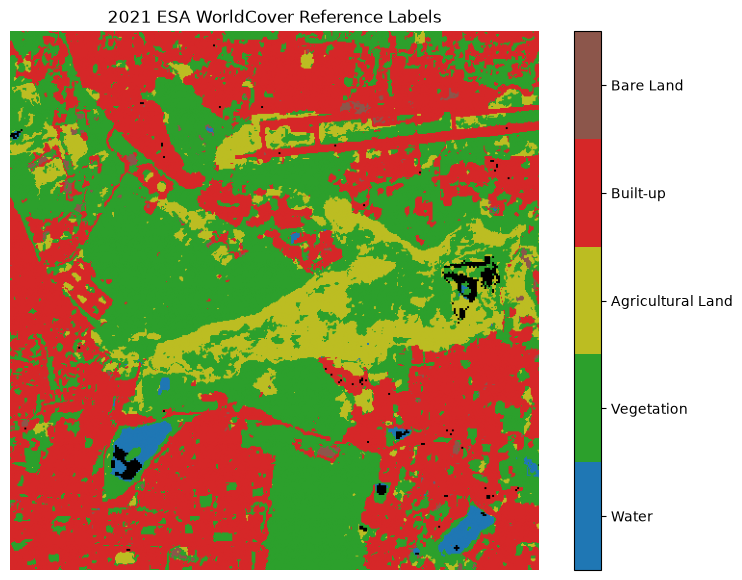

In [306]:
def show_class_map(
    class_map,
    title
):

    masked = np.ma.masked_where(
        class_map < 0,
        class_map
    )

    cmap = plt.matplotlib.colors.ListedColormap(
        [
            CLASS_COLORS[i]
            for i in range(5)
        ]
    )

    cmap.set_bad("black")

    plt.figure(
        figsize=(9, 7)
    )

    plt.imshow(
        masked,
        cmap=cmap,
        vmin=-0.5,
        vmax=4.5
    )

    cbar = plt.colorbar(
        ticks=range(5)
    )

    cbar.ax.set_yticklabels(
        [
            CLASS_NAMES[i]
            for i in range(5)
        ]
    )

    plt.title(title)
    plt.axis("off")
    plt.show()


show_class_map(
    worldcover_labels,
    "2021 ESA WorldCover Reference Labels"
)

# 13. Spatial Block Train–Validation Split

A spatial block hold-out strategy is used instead of randomly splitting individual pixels.

The image is divided into a regular grid, and complete blocks are reserved for validation. This reduces spatial leakage caused by highly correlated neighbouring pixels appearing in both training and validation sets.

In [307]:
def make_spatial_split(
    labels,
    n_rows=4,
    n_cols=4
):

    h, w = labels.shape

    block_h = h // n_rows
    block_w = w // n_cols

    validation_blocks = {
        1, 7, 9, 14
    }

    train_mask = np.zeros(
        labels.shape,
        dtype=bool
    )

    val_mask = np.zeros(
        labels.shape,
        dtype=bool
    )

    block_id_map = np.full(
        labels.shape,
        -1,
        dtype=np.int16
    )

    block_id = 0

    for r in range(n_rows):

        for c in range(n_cols):

            y0 = r * block_h
            y1 = (
                (r + 1) * block_h
                if r < n_rows - 1
                else h
            )

            x0 = c * block_w
            x1 = (
                (c + 1) * block_w
                if c < n_cols - 1
                else w
            )

            block_id_map[
                y0:y1,
                x0:x1
            ] = block_id

            if block_id in validation_blocks:

                val_mask[
                    y0:y1,
                    x0:x1
                ] = True

            else:

                train_mask[
                    y0:y1,
                    x0:x1
                ] = True

            block_id += 1

    train_mask &= labels >= 0
    val_mask &= labels >= 0

    return (
        train_mask,
        val_mask,
        block_id_map
    )


train_spatial, val_spatial, block_ids = make_spatial_split(
    worldcover_labels
)

print(
    "Training reference pixels:",
    train_spatial.sum()
)

print(
    "Validation reference pixels:",
    val_spatial.sum()
)

print(
    "Validation blocks:",
    sorted(
        np.unique(
            block_ids[val_spatial]
        ).tolist()
    )
)

Training reference pixels: 230092
Validation reference pixels: 75860
Validation blocks: [1, 7, 9, 14]


# 14. Training and Validation Sample Preparation

Samples are drawn separately from the spatial training and validation regions.

Up to 2,000 training pixels and 500 validation pixels are sampled per class. This limits the influence of large classes while retaining a balanced validation set for class-wise performance comparison.

In [308]:
rng = np.random.default_rng(42)


def sample_pixels(
    X,
    labels,
    spatial_mask,
    max_per_class=2000
):

    X_flat = X.reshape(
        -1,
        X.shape[-1]
    )

    y_flat = labels.ravel()

    mask_flat = spatial_mask.ravel()

    selected = []

    for cls in range(5):

        idx = np.where(
            mask_flat &
            (y_flat == cls)
        )[0]

        if len(idx) == 0:
            print(
                f"Warning: no pixels for {CLASS_NAMES[cls]}"
            )
            continue

        if len(idx) > max_per_class:

            idx = rng.choice(
                idx,
                size=max_per_class,
                replace=False
            )

        selected.append(idx)

    selected = np.concatenate(
        selected
    )

    return (
        X_flat[selected],
        y_flat[selected]
    )


X_train, y_train = sample_pixels(
    features[2021],
    worldcover_labels,
    train_spatial,
    max_per_class=2000
)

X_val, y_val = sample_pixels(
    features[2021],
    worldcover_labels,
    val_spatial,
    max_per_class=500
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

print("\nTraining class distribution:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nValidation class distribution:")
print(
    pd.Series(y_val)
    .value_counts()
    .sort_index()
)

Training: (9730, 11)
Validation: (2500, 11)

Training class distribution:
0    2000
1    2000
2    2000
3    2000
4    1730
Name: count, dtype: int64

Validation class distribution:
0    500
1    500
2    500
3    500
4    500
Name: count, dtype: int64


# 15. Random Forest Land-Cover Classifier

A Random Forest classifier is trained on the 2021 Sentinel-2 feature stack using the reference labels.

The configuration uses 300 trees, controlled tree depth, a minimum leaf size, square-root feature sampling, balanced class weights, and a fixed random seed for reproducibility.

In [310]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

print("Random Forest trained.")

Random Forest trained.


# 16. Model Validation Results

The trained model is evaluated only on the spatially separated validation pixels.

Overall accuracy is reported together with balanced accuracy, macro F1, weighted F1, macro precision, and macro recall. Macro metrics are particularly useful here because they give equal importance to each land-cover class.

In [311]:
y_pred_val = rf.predict(
    X_val
)

metrics = {
    "Overall Accuracy": accuracy_score(
        y_val,
        y_pred_val
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val,
        y_pred_val
    ),

    "Macro F1": f1_score(
        y_val,
        y_pred_val,
        average="macro"
    ),

    "Weighted F1": f1_score(
        y_val,
        y_pred_val,
        average="weighted"
    ),

    "Macro Precision": precision_score(
        y_val,
        y_pred_val,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val,
        y_pred_val,
        average="macro",
        zero_division=0
    )
}

metrics_df = pd.DataFrame({
    "Metric": list(metrics.keys()),
    "Score (%)": [
        value * 100
        for value in metrics.values()
    ]
})

display(
    metrics_df.round(2)
)

,Metric,Score (%)
0,Overall Accuracy,71.72
1,Balanced Accuracy,71.72
2,Macro F1,71.56
3,Weighted F1,71.56
4,Macro Precision,72.08
5,Macro Recall,71.72


# 17. Spatial Hold-Out Confusion Matrix

The confusion matrix summarizes reference-versus-predicted classes for the spatial validation set.

It helps identify which classes are consistently recognized and which classes are commonly confused with one another.

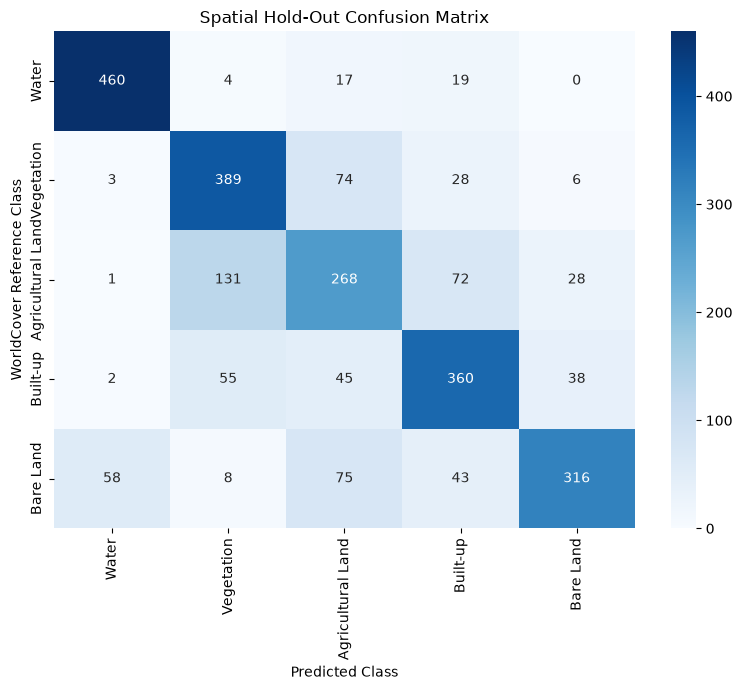

In [312]:
cm = confusion_matrix(
    y_val,
    y_pred_val,
    labels=list(range(5))
)

plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        CLASS_NAMES[i]
        for i in range(5)
    ],
    yticklabels=[
        CLASS_NAMES[i]
        for i in range(5)
    ]
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "WorldCover Reference Class"
)

plt.title(
    "Spatial Hold-Out Confusion Matrix"
)

plt.tight_layout()
plt.show()

# 18. Class-Wise Classification Performance

Precision, recall, and F1-score are reported for each land-cover class.

The validation results show that Water is the strongest-performing class, while Agricultural Land is more difficult to distinguish from other classes.

In [313]:
print(
    classification_report(
        y_val,
        y_pred_val,
        target_names=[
            CLASS_NAMES[i]
            for i in range(5)
        ],
        zero_division=0
    )
)

                   precision    recall  f1-score   support

            Water       0.88      0.92      0.90       500
       Vegetation       0.66      0.78      0.72       500
Agricultural Land       0.56      0.54      0.55       500
         Built-up       0.69      0.72      0.70       500
        Bare Land       0.81      0.63      0.71       500

         accuracy                           0.72      2500
        macro avg       0.72      0.72      0.72      2500
     weighted avg       0.72      0.72      0.72      2500



# 19. Temporal Land-Cover Classification

The trained 2021 Random Forest model is applied to the valid pixels of the 2021, 2023, and 2025 feature stacks.

Using the same trained model and the same five-class scheme makes the three outputs directly comparable, while the later-year predictions remain model estimates rather than independently validated reference maps.

In [314]:
def classify_image(
    X,
    valid_mask,
    model
):

    h, w, n_features = X.shape

    flat = X.reshape(
        -1,
        n_features
    )

    valid = valid_mask.ravel()

    prediction = np.full(
        flat.shape[0],
        -1,
        dtype=np.int8
    )

    prediction[valid] = model.predict(
        flat[valid]
    )

    return prediction.reshape(
        h,
        w
    )


classifications = {}

for year in DATES:

    classifications[year] = classify_image(
        features[year],
        data[year]["valid_mask"].values,
        rf
    )

    print(
        year,
        classifications[year].shape
    )

print(
    "All three land-cover maps generated."
)

2021 (560, 550)
2023 (560, 550)
2025 (560, 550)
All three land-cover maps generated.


# 20. Temporal Class Distribution

The predicted pixel counts and percentages are summarized for each year.

These distributions provide a compact numerical comparison of the estimated land-cover composition before converting pixel counts into area.

In [ ]:

prediction_distribution_rows = []

for year in classifications:

    classification = classifications[year]

    valid = classification >= 0

    total = valid.sum()

    print(
        f"\n{'=' * 20} {year} {'=' * 20}"
    )

    for cls in range(5):

        pixels = np.sum(
            classification == cls
        )

        percentage = (
            pixels / total * 100
            if total > 0
            else 0
        )

        prediction_distribution_rows.append({
            "Year": year,
            "Class": CLASS_NAMES[cls],
            "Pixels": int(pixels),
            "Percentage": percentage
        })

        print(
            f"{CLASS_NAMES[cls]:20s}: "
            f"{pixels:7d} pixels "
            f"({percentage:6.2f}%)"
        )

prediction_distribution_df = pd.DataFrame(
    prediction_distribution_rows
)

display(
    prediction_distribution_df.round(2)
)


==================== 2021 ====================
Water               :    5480 pixels (  1.79%)
Vegetation          :  115840 pixels ( 37.86%)
Agricultural Land   :   57719 pixels ( 18.87%)
Built-up            :  109491 pixels ( 35.79%)
Bare Land           :   17422 pixels (  5.69%)

==================== 2023 ====================
Water               :   14368 pixels (  4.67%)
Vegetation          :  128512 pixels ( 41.73%)
Agricultural Land   :   45530 pixels ( 14.78%)
Built-up            :   99329 pixels ( 32.25%)
Bare Land           :   20243 pixels (  6.57%)

==================== 2025 ====================
Water               :   15246 pixels (  4.95%)
Vegetation          :  129989 pixels ( 42.20%)
Agricultural Land   :   38221 pixels ( 12.41%)
Built-up            :  108568 pixels ( 35.25%)
Bare Land           :   15976 pixels (  5.19%)


,Year,Class,Pixels,Percentage
0,2021,Water,5480,1.79
1,2021,Vegetation,115840,37.86
2,2021,Agricultural Land,57719,18.87
3,2021,Built-up,109491,35.79
4,2021,Bare Land,17422,5.69
5,2023,Water,14368,4.67
6,2023,Vegetation,128512,41.73
7,2023,Agricultural Land,45530,14.78
8,2023,Built-up,99329,32.25
9,2023,Bare Land,20243,6.57


# 21. Land-Cover Classification Maps: 2021–2025

The three maps show the spatial distribution of the five model-predicted land-cover classes for the same AOI.

Because the images share a common 10 m grid, the maps can be compared spatially across years.

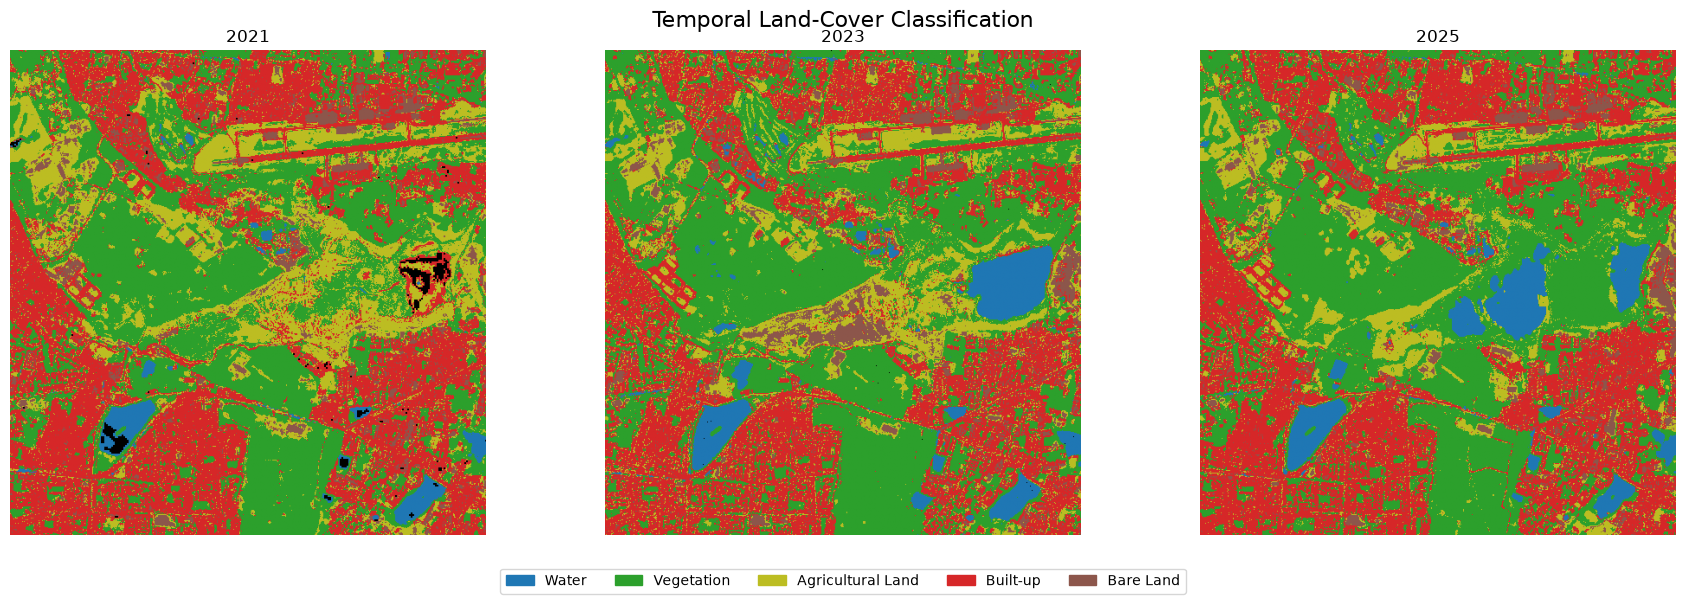

In [316]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

cmap = plt.matplotlib.colors.ListedColormap(
    [
        CLASS_COLORS[i]
        for i in range(5)
    ]
)

cmap.set_bad("black")

for ax, year in zip(
    axes,
    DATES
):

    masked = np.ma.masked_where(
        classifications[year] < 0,
        classifications[year]
    )

    ax.imshow(
        masked,
        cmap=cmap,
        vmin=-0.5,
        vmax=4.5
    )

    ax.set_title(
        str(year)
    )

    ax.axis("off")


handles = [
    plt.matplotlib.patches.Patch(
        color=CLASS_COLORS[i],
        label=CLASS_NAMES[i]
    )
    for i in range(5)
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=5
)

fig.suptitle(
    "Temporal Land-Cover Classification",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)

plt.show()

# 22. Class-Wise Land-Cover Area

At 10 m spatial resolution, each valid pixel represents 100 m², or 0.0001 km².

Pixel counts are therefore converted to square kilometres and percentages of the valid analysis area for each year.

In [317]:
PIXEL_AREA_M2 = RESOLUTION * RESOLUTION
PIXEL_AREA_KM2 = (
    PIXEL_AREA_M2 / 1_000_000
)


def area_table(classification):

    valid = classification >= 0

    total_valid = valid.sum()

    rows = []

    for cls in range(5):

        pixels = np.sum(
            classification == cls
        )

        area_km2 = (
            pixels *
            PIXEL_AREA_KM2
        )

        percentage = (
            pixels /
            total_valid *
            100
            if total_valid > 0
            else 0
        )

        rows.append({
            "Class": CLASS_NAMES[cls],
            "Pixels": int(pixels),
            "Area (km²)": area_km2,
            "Percentage (%)": percentage
        })

    return pd.DataFrame(rows)


area_tables = {}

for year in DATES:

    table = area_table(
        classifications[year]
    )

    table.insert(
        0,
        "Year",
        year
    )

    area_tables[year] = table


area_summary = pd.concat(
    area_tables.values(),
    ignore_index=True
)

display(
    area_summary.round(4)
)

,Year,Class,Pixels,Area (km²),Percentage (%)
0,2021,Water,5480,0.5480,1.7911
1,2021,Vegetation,115840,11.5840,37.8621
2,2021,Agricultural Land,57719,5.7719,18.8654
3,2021,Built-up,109491,10.9491,35.7870
4,2021,Bare Land,17422,1.7422,5.6944
5,2023,Water,14368,1.4368,4.6652
6,2023,Vegetation,128512,12.8512,41.7271
7,2023,Agricultural Land,45530,4.5530,14.7833
8,2023,Built-up,99329,9.9329,32.2516
9,2023,Bare Land,20243,2.0243,6.5728


# 23. Land-Cover Area Comparison Across Years

The table below presents the estimated area of each land-cover class for 2021, 2023, and 2025.

The values should be interpreted as model-derived estimates based on the same classification framework applied to each year's imagery.


In [318]:
area_pivot = area_summary.pivot(
    index="Class",
    columns="Year",
    values="Area (km²)"
)

display(
    area_pivot.round(4)
)

Year,2021,2023,2025
Class,,,
Agricultural Land,5.7719,4.5530,3.8221
Bare Land,1.7422,2.0243,1.5976
Built-up,10.9491,9.9329,10.8568
Vegetation,11.5840,12.8512,12.9989
Water,0.5480,1.4368,1.5246


# 24. Temporal Land-Cover Area Trends

The line plot visualizes how the estimated area of each land-cover class changes across the three observation years.

The trend is descriptive rather than a statistically fitted time series because only three dates are available.

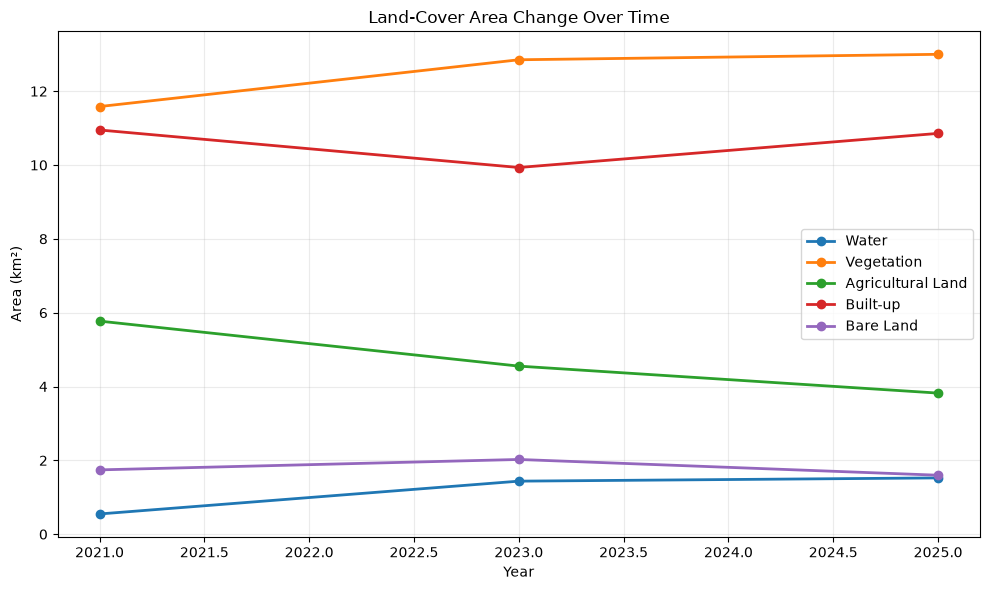

In [319]:
plt.figure(
    figsize=(10, 6)
)

for cls in CLASS_NAMES.values():

    values = area_pivot.loc[
        cls,
        [2021, 2023, 2025]
    ]

    plt.plot(
        [2021, 2023, 2025],
        values,
        marker="o",
        linewidth=2,
        label=cls
    )

plt.xlabel("Year")
plt.ylabel("Area (km²)")

plt.title(
    "Land-Cover Area Change Over Time"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

# 25. Net Land-Cover Change: 2021–2025

Net change is calculated between the first and last observation year.

Positive values indicate an increase in estimated area, while negative values indicate a decrease. Percentage change is calculated relative to the 2021 estimated area.

In [320]:
change_rows = []

for cls in CLASS_NAMES.values():

    area_2021 = area_pivot.loc[
        cls,
        2021
    ]

    area_2025 = area_pivot.loc[
        cls,
        2025
    ]

    net_change = (
        area_2025 -
        area_2021
    )

    percentage_change = (
        net_change /
        area_2021 *
        100
        if area_2021 != 0
        else np.nan
    )

    change_rows.append({
        "Class": cls,
        "2021 Area (km²)": area_2021,
        "2025 Area (km²)": area_2025,
        "Net Change (km²)": net_change,
        "Change (%)": percentage_change
    })


change_df = pd.DataFrame(
    change_rows
)

display(
    change_df.round(4)
)

,Class,2021 Area (km²),2025 Area (km²),Net Change (km²),Change (%)
0,Water,0.5480,1.5246,0.9766,178.2117
1,Vegetation,11.5840,12.9989,1.4149,12.2143
2,Agricultural Land,5.7719,3.8221,-1.9498,-33.7809
3,Built-up,10.9491,10.8568,-0.0923,-0.8430
4,Bare Land,1.7422,1.5976,-0.1446,-8.2999


# 26. Land-Cover Transition Matrix: 2021–2025

The transition matrix compares the predicted class of each pixel in 2021 with its predicted class in 2025.

It provides additional information beyond class-area totals by showing the estimated class-to-class transitions across the common valid area.

In [321]:
map_2021 = classifications[2021]
map_2025 = classifications[2025]

common_valid = (
    (map_2021 >= 0) &
    (map_2025 >= 0)
)

transition_matrix = confusion_matrix(
    map_2021[common_valid],
    map_2025[common_valid],
    labels=list(range(5))
)

transition_df = pd.DataFrame(
    transition_matrix,
    index=[
        CLASS_NAMES[i]
        for i in range(5)
    ],
    columns=[
        CLASS_NAMES[i]
        for i in range(5)
    ]
)

display(
    transition_df
)

,Water,Vegetation,Agricultural Land,Built-up,Bare Land
Water,4370,498,212,300,100
Vegetation,3693,94407,8999,7291,1450
Agricultural Land,3889,22240,20965,7732,2893
Built-up,1792,11446,5670,86147,4436
Bare Land,141,980,2323,6918,7060


# 27. Major Land-Cover Transitions

The off-diagonal transitions are ranked by pixel count to identify the largest estimated class-to-class changes.

These transitions indicate modelled changes in class assignment and should not be interpreted as independently verified land-cover conversions.

In [322]:
transition_rows = []

for source in range(5):

    for target in range(5):

        if source == target:
            continue

        pixels = transition_matrix[
            source,
            target
        ]

        if pixels == 0:
            continue

        transition_rows.append({
            "From Class": CLASS_NAMES[source],
            "To Class": CLASS_NAMES[target],
            "Pixels": int(pixels),
            "Area (km²)": (
                pixels *
                PIXEL_AREA_KM2
            )
        })


major_transitions = pd.DataFrame(
    transition_rows
)

major_transitions = (
    major_transitions
    .sort_values(
        "Pixels",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    major_transitions.head(10).round(4)
)

,From Class,To Class,Pixels,Area (km²)
0,Agricultural Land,Vegetation,22240,2.2240
1,Built-up,Vegetation,11446,1.1446
2,Vegetation,Agricultural Land,8999,0.8999
3,Agricultural Land,Built-up,7732,0.7732
4,Vegetation,Built-up,7291,0.7291
5,Bare Land,Built-up,6918,0.6918
6,Built-up,Agricultural Land,5670,0.5670
7,Built-up,Bare Land,4436,0.4436
8,Agricultural Land,Water,3889,0.3889
9,Vegetation,Water,3693,0.3693


# 28. Spectral Feature Importance

Random Forest feature importance is used as a model-level diagnostic to identify which input features contributed most to the classification decisions.

Higher importance indicates greater contribution within this fitted Random Forest; it does not by itself establish causal importance.

,Feature,Importance
4,B11_SWIR1,0.1743
5,B12_SWIR2,0.1555
2,B04_Red,0.1232
7,NDWI,0.1164
0,B02_Blue,0.0876
3,B08_NIR,0.0803
6,NDVI,0.0745
1,B03_Green,0.0568
9,SAVI,0.0460
10,EVI,0.0435


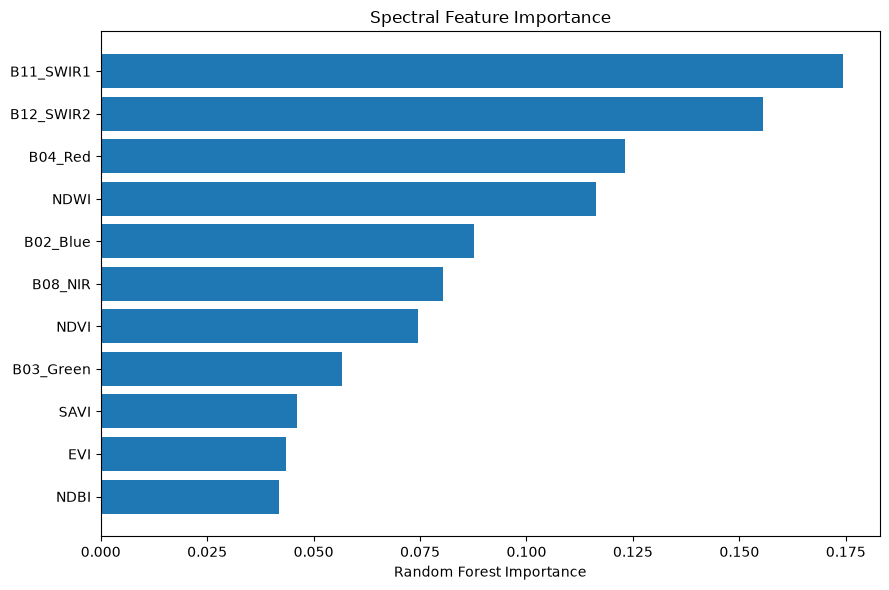

In [323]:
importance_df = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(
    importance_df.round(4)
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)

plt.xlabel(
    "Random Forest Importance"
)

plt.title(
    "Spectral Feature Importance"
)

plt.tight_layout()

plt.show()

# 29. Export of Analysis Results

Key metadata, validation metrics, land-cover areas, temporal changes, transition matrices, and feature importance results are exported as CSV files.

This keeps the main numerical outputs reproducible and available for downstream analysis.

In [324]:
OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(
    exist_ok=True
)

# Tables
scene_table.to_csv(
    OUTPUT_DIR / "scene_metadata.csv",
    index=False
)

metrics_df.to_csv(
    OUTPUT_DIR / "validation_metrics.csv",
    index=False
)

area_summary.to_csv(
    OUTPUT_DIR / "land_cover_area_summary.csv",
    index=False
)

change_df.to_csv(
    OUTPUT_DIR / "land_cover_change_2021_2025.csv",
    index=False
)

transition_df.to_csv(
    OUTPUT_DIR / "transition_matrix_2021_2025.csv"
)

major_transitions.to_csv(
    OUTPUT_DIR / "major_transitions_2021_2025.csv",
    index=False
)

importance_df.to_csv(
    OUTPUT_DIR / "feature_importance.csv",
    index=False
)

print(
    f"Outputs saved to: {OUTPUT_DIR.resolve()}"
)

Outputs saved to: /Users/shwetha/Downloads/outputs


# 30. Interpretation of Temporal Land-Cover Changes

The classification results show measurable differences in the estimated spatial distribution of land-cover classes across the Bengaluru AOI between 2021, 2023, and 2025.

From 2021 to 2025, the model estimates an increase in vegetation from approximately **11.58 km² to 13.00 km²**, corresponding to a **12.21% increase**. Estimated water area also increased from **0.55 km² to 1.52 km²**. In contrast, agricultural land decreased from approximately **5.77 km² to 3.82 km²**, representing a **33.78% decrease**.

Built-up area remained relatively stable over the complete period, changing from **10.95 km² in 2021 to 10.86 km² in 2025** (−0.84%). Bare land decreased slightly from **1.74 km² to 1.60 km²** (−8.30%).

The transition analysis provides additional information about the estimated class changes. The largest estimated transition was **Agricultural Land → Vegetation**, followed by **Built-up → Vegetation** and **Vegetation → Agricultural Land**. These transitions describe changes in model-predicted class assignments and should not be interpreted as confirmed physical land-cover conversions.

Because the Random Forest model was trained using 2021 ESA WorldCover reference labels and then applied to 2023 and 2025 imagery, some temporal differences may result from changes in spectral conditions, atmospheric effects, acquisition conditions, or classification uncertainty. Therefore, the results are best interpreted as a consistent model-based temporal comparison rather than independently validated land-cover maps for every year.

# 31. Limitations

1. **Reference-label availability:** ESA WorldCover 2021 is used as the primary reference dataset. Independently validated reference labels are not available for 2023 and 2025.

2. **Cross-year model transfer:** The Random Forest classifier is trained using 2021 reference labels and applied to all three years. Temporal differences may therefore reflect both actual land-cover changes and differences in spectral characteristics between acquisition dates.

3. **Acquisition variability:** The selected images are from approximately the same period of the year, which reduces seasonal differences but does not eliminate differences caused by atmospheric conditions, illumination, vegetation state, or acquisition conditions.

4. **Class confusion:** Agricultural Land and Vegetation can have similar spectral responses. This is reflected in the comparatively lower Agricultural Land F1-score of approximately **0.55**.

5. **Class aggregation:** Multiple ESA WorldCover categories are grouped into five project-specific classes, which simplifies the original classification scheme and introduces some mapping uncertainty.

6. **Single acquisition per year:** One Sentinel-2 acquisition is used for each year. Seasonal composites or multi-date observations could provide more robust land-cover estimates.

7. **Interpretation of change:** Reported area differences and transition counts are model-derived estimates and should not be treated as independently verified ground-truth land-cover conversions.

8. **Model choice:** Random Forest provides a strong and interpretable baseline, but more advanced ensemble or deep-learning approaches could potentially improve class separation and spatial consistency.

# 32. Conclusion

This project presents an end-to-end temporal land-cover classification workflow using Sentinel-2 Level-2A imagery for a fixed Bengaluru AOI across **2021, 2023, and 2025**.

The workflow combines satellite-scene selection, common-grid reprojection, SCL-based quality masking, metadata-driven radiometric preprocessing, spectral feature engineering, ESA WorldCover reference-label preparation, spatial hold-out validation, Random Forest classification, class-wise area estimation, temporal comparison, transition analysis, and feature-importance analysis.

The classifier achieved approximately **71.7% overall accuracy** and **71.6% macro F1-score** on the spatial hold-out validation set. Water was the strongest-performing class, while Agricultural Land was the most challenging class to distinguish.

The temporal outputs estimate an increase in vegetation and water area between 2021 and 2025, a decrease in agricultural land and bare land, and relatively stable built-up area. Transition analysis further identifies the dominant model-estimated class changes.

Overall, the project demonstrates a practical machine-learning workflow for multi-year land-cover analysis while clearly distinguishing model-derived temporal patterns from independently validated land-cover change.